# Classificador de Risco de Incidentes — UNSW-NB15 (Cyber Security)

Este projeto tem como objetivo realizar uma análise profissional de tráfego de rede baseado no dataset UNSW-NB15, utilizando técnicas modernas de Data Science aplicadas ao contexto de Segurança da Informação.  
Aqui, classificamos diferentes tipos de ataques cibernéticos e, mais importante, explicamos **por que** o modelo toma suas decisões — trazendo transparência para a interpretação do risco.

---

## Técnicas utilizadas

| Etapa | Técnicas Aplicadas |
|------:|---------------------|
| Pré-processamento | Amostragem, normalização, identificação de features, One-Hot Encoding |
| EDA (Exploratory Data Analysis) | Estatísticas, análises de distribuição e gráficos interpretativos de Protocolo / Serviço / Estado de conexão |
| Modelagem | LightGBM (modelo de classificação multi-classe) |
| Interpretação de Modelo | SHAP (Explainable AI — Feature Importance + Waterfall individual) |

---

## Objetivo do projeto

- Criar um classificador capaz de identificar a categoria de ataque com base em atributos de tráfego de rede.
- Analisar quais variáveis exercem maior influência no risco de um incidente.
- Tornar o processo de predição **explicável e auditável**, mostrando “o que” leva o modelo a decidir.

  Ou seja, não é apenas classificar é **interpretar** risco.

---

## Resultado Final

O modelo conseguiu identificar quais features mais contribuem para ataques do tipo “Generic”, revelando padrões importantes, como:

- certos serviços (ex: DNS)
- certos protocolos (UDP)
- certos estados de conexão (FIN / INT)
- métricas numéricas específicas do fluxo de rede (sbytes / dbytes etc.)

Além disso, um gráfico waterfall SHAP mostra, caso a caso, quais variáveis empurram uma previsão para **ataque** ou para **normal**.

Em termos de aplicabilidade, este notebook pode servir como base para:

- análises SOC
- investigações forenses
- estudo de telemetria de rede
- demonstração técnica profissional em portfólio

---

> Em resumo: este notebook é um exemplo de análise de segurança com foco em **classificação + interpretação de risco**, utilizando inteligência artificial aplicada ao contexto de cyber security.


### 1) Instalação de dependências externas
Instala as bibliotecas necessárias para o projeto:  
- `kagglehub` para baixar datasets do Kaggle de forma programática  
- `shap` para realizar explicabilidade de modelo usando SHAP values



In [58]:
!pip install kagglehub
!pip install shap


### 2) Download do dataset UNSW-NB15 via KaggleHub
Faz o download automático do dataset UNSW-NB15 diretamente do Kaggle, armazenando os arquivos localmente para uso no projeto.


In [59]:
import kagglehub

path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")
print("Path to dataset files:", path)


Path to dataset files: /root/.cache/kagglehub/datasets/mrwellsdavid/unsw-nb15/versions/1


### 3) Listagem dos arquivos baixados do dataset
Lista todos os arquivos existentes na pasta baixada, permitindo visualizar quais CSVs fazem parte do dataset UNSW-NB15 antes do carregamento e processamento.


In [60]:
import os

path = "/root/.cache/kagglehub/datasets/mrwellsdavid/unsw-nb15/versions/1"
files = os.listdir(path)
for f in files:
    print(f)


UNSW_NB15_testing-set.csv
UNSW-NB15_LIST_EVENTS.csv
UNSW-NB15_1.csv
NUSW-NB15_features.csv
UNSW-NB15_4.csv
UNSW-NB15_2.csv
UNSW-NB15_3.csv
UNSW_NB15_training-set.csv


### 4) Amostragem do dataset para reduzir volume
Seleciona aleatoriamente 200.000 registros do dataset original para tornar o processamento e visualização mais rápidos e leves no Colab, mantendo representatividade estatística.


In [61]:
df = df.sample(n=200_000, random_state=42).reset_index(drop=True)
print("Novo shape reduzido:", df.shape)


Novo shape reduzido: (200000, 46)


### 5) Carregamento dos arquivos CSV e concatenação do dataset
Carrega os arquivos de treino e teste oficiais do UNSW-NB15 e concatena ambos em um único DataFrame `df`.  
Isso facilita o processamento unificado, já que o dataset vem originalmente separado em dois blocos pelo Kaggle.


In [62]:
import pandas as pd

base_path = "/root/.cache/kagglehub/datasets/mrwellsdavid/unsw-nb15/versions/1"

train = pd.read_csv(f"{base_path}/UNSW_NB15_training-set.csv")
test  = pd.read_csv(f"{base_path}/UNSW_NB15_testing-set.csv")

df = pd.concat([train, test], ignore_index=True)

print("Shape:", df.shape)
print(df.head())
print(df.columns[:20])


Shape: (257673, 45)
   id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0   1  0.000011   udp       -   INT      2      0     496       0   
1   2  0.000008   udp       -   INT      2      0    1762       0   
2   3  0.000005   udp       -   INT      2      0    1068       0   
3   4  0.000006   udp       -   INT      2      0     900       0   
4   5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  \
0   90909.0902  ...                 1               2             0   
1  125000.0003  ...                 1               2             0   
2  200000.0051  ...                 1               3             0   
3  166666.6608  ...                 1               3             0   
4  100000.0025  ...                 1               3             0   

   ct_ftp_cmd  ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  \
0           0                 0           1           2       

### 6) Normalização dos nomes das colunas + identificação da coluna de ataque
Converte todos os nomes de colunas para um padrão uniforme (minúsculas e sem espaços / hífens) e procura automaticamente qual coluna contém a informação de categoria de ataque (“attack_cat”), que será usada como variável alvo (target) do modelo.


In [63]:
# Normalizar nomes de colunas
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)

# Procurar coluna com word "attack"
attack_col_candidates = [c for c in df.columns if 'attack' in c]

print("Candidatos encontrados para coluna de ataque:")
print(attack_col_candidates)


Candidatos encontrados para coluna de ataque:
['attack_cat']


### 7) Distribuição das classes de ataque
Conta quantos registros existem em cada categoria de ataque dentro do dataset, permitindo visualizar o balanceamento das classes antes de qualquer modelagem.


In [64]:
vc = df['attack_cat'].value_counts(dropna=False)
vc


,count
attack_cat,
Normal,93000
Generic,58871
Exploits,44525
Fuzzers,24246
DoS,16353
Reconnaissance,13987
Analysis,2677
Backdoor,2329
Shellcode,1511


### 8) Gráfico de distribuição das categorias de ataque
Gera um gráfico de barras mostrando quantos registros existem por tipo de ataque no dataset, facilitando a visualização do desbalanceamento entre as classes e a predominância de determinadas categorias.


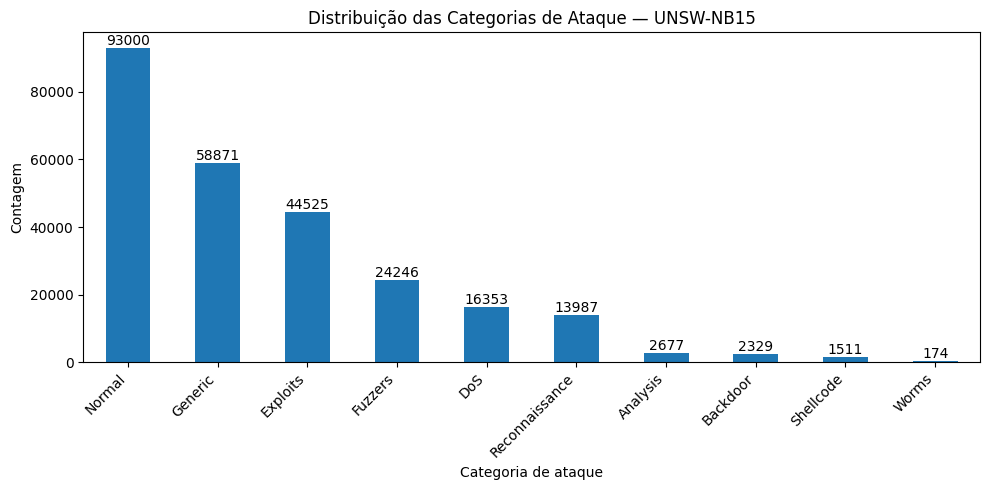

In [65]:
import matplotlib.pyplot as plt

counts = df['attack_cat'].value_counts()

plt.figure(figsize=(10,5))
counts.plot(kind='bar')
plt.title('Distribuição das Categorias de Ataque — UNSW-NB15')
plt.xlabel('Categoria de ataque')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')

# adicionar labels em cima das barras
for idx, value in enumerate(counts):
    plt.text(idx, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()


### 9) Criação da variável binária Normal vs Attack + gráfico de distribuição
Cria a coluna `is_attack`, que transforma a classificação multiclasse em uma visão binária (Normal x Ataque) e plota essa distribuição.  
Esse gráfico é útil para mostrar o desequilíbrio natural entre tráfego legítimo e malicioso.


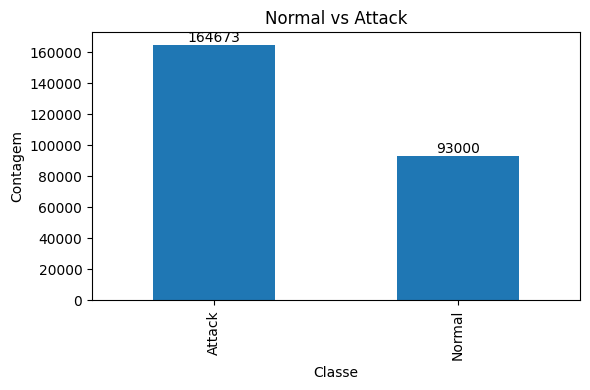

In [66]:
import matplotlib.pyplot as plt

df['is_attack'] = df['attack_cat'].apply(lambda x: 'Normal' if x == 'Normal' else 'Attack')

counts_bin = df['is_attack'].value_counts()

plt.figure(figsize=(6,4))
counts_bin.plot(kind='bar')
plt.title('Normal vs Attack')
plt.xlabel('Classe')
plt.ylabel('Contagem')

for idx, value in enumerate(counts_bin):
    plt.text(idx, value, str(value), ha='center', va='bottom')

plt.tight_layout()
plt.show()


### 10) Identificação das colunas numéricas e categóricas do dataset
Detecta automaticamente quais colunas são numéricas e quais são categóricas.  
Essa separação é importante porque as técnicas de pré-processamento e modelagem tratam cada tipo de dado de forma diferente (ex.: One-Hot Encoding para categóricas).


In [67]:
# identificar colunas numéricas e categóricas
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", len(num_cols))
print(num_cols[:20])
print("\nCategóricas:", len(cat_cols))
print(cat_cols[:20])


Numéricas: 41
['id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb']

Categóricas: 5
['proto', 'service', 'state', 'attack_cat', 'is_attack']


### 11) Identificação das 8 categorias mais comuns em cada coluna categórica-chave
Mostra as 8 categorias mais frequentes nas colunas `proto`, `service` e `state`.  
Isso permite selecionar apenas os elementos mais representativos destas features para gerar gráficos mais limpos e interpretáveis, evitando poluição visual causada por categorias raras.


In [68]:
for col in ['proto', 'service', 'state']:
    print(f"\nTop categorias de {col}")
    print(df[col].value_counts().head(8))



Top categorias de proto
proto
tcp     123041
udp      92701
unas     15599
arp       3846
ospf      3271
sctp      1474
any        396
gre        313
Name: count, dtype: int64

Top categorias de service
service
-           141321
dns          68661
http         27011
smtp          6909
ftp-data      5391
ftp           4980
pop3          1528
ssh           1506
Name: count, dtype: int64

Top categorias de state
state
FIN    117164
INT    116438
CON     20134
REQ      3833
RST        84
ECO        12
ACC         4
CLO         1
Name: count, dtype: int64


### 12) Análise das Top 8 categorias por Protocolo / Serviço / Estado com Taxa de Ataque
Gera gráficos comparando a *taxa percentual de ataques* para as 8 categorias mais frequentes de `proto`, `service` e `state`.  
Além disso, imprime logo abaixo de cada gráfico um texto explicativo traduzindo cada termo técnico para linguagem clara, facilitando o entendimento do leitor sobre o que cada categoria representa no contexto de tráfego de rede.


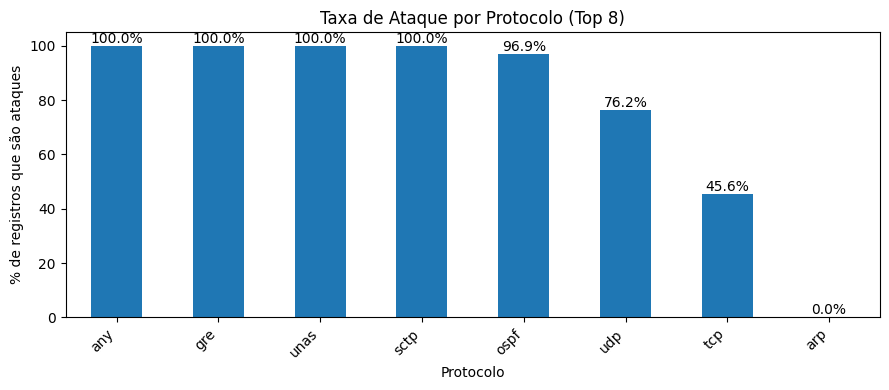


📌 Interpretação — Protocolo
 - any: ANY — protocolo genérico / não identificado
 - gre: GRE — tunelamento encapsulado
 - unas: UNAS — serviço desconhecido / não classificado
 - sctp: SCTP — multi-stream (mais raro)
 - ospf: OSPF — protocolo de roteamento interno
 - udp: UDP — sem conexão (DNS / VoIP / streaming)
 - tcp: TCP — orientado à conexão (tráfego mais comum da web)
 - arp: ARP — resolução de endereços MAC

--------------------------------------------------------------------------------



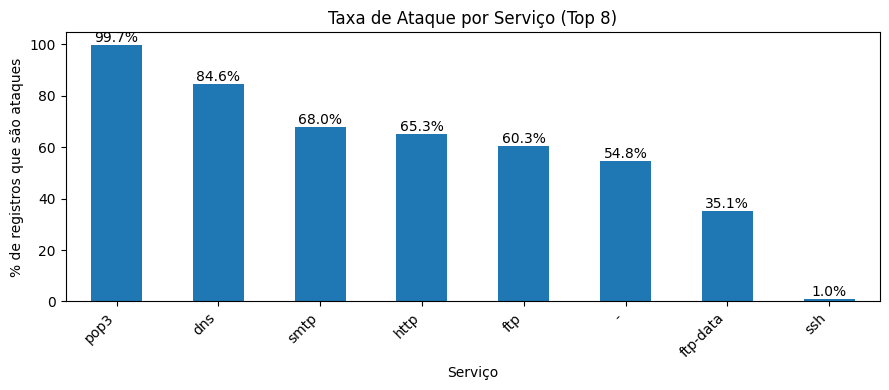


📌 Interpretação — Serviço
 - pop3: POP3 — recebimento de e-mail
 - dns: Serviço DNS — resolução de domínios
 - smtp: SMTP — envio de e-mail
 - http: HTTP — navegação web
 - ftp: FTP — acesso a servidor de arquivos
 - -: Não identificado / desconhecido
 - ftp-data: FTP DATA — transferência de arquivos
 - ssh: SSH — acesso remoto seguro

--------------------------------------------------------------------------------



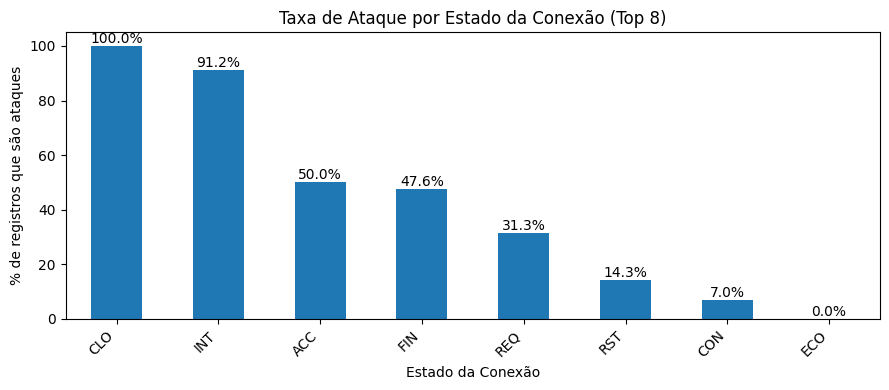


📌 Interpretação — Estado da Conexão
 - CLO: CLO — closed
 - INT: INT — conexão interrompida
 - ACC: ACC — accept
 - FIN: FIN — conexão finalizada
 - REQ: REQ — requisição enviada
 - RST: RST — reset de conexão (anormal)
 - CON: CON — conexão estabelecida
 - ECO: ECO — echo request (tipo ping)

--------------------------------------------------------------------------------



In [69]:
import matplotlib.pyplot as plt

labels_pt = {
    'proto': 'Protocolo',
    'service': 'Serviço',
    'state': 'Estado da Conexão'
}

# dicionários de explicação técnica PT-BR:
explicacoes_proto = {
    'tcp': 'TCP — orientado à conexão (tráfego mais comum da web)',
    'udp': 'UDP — sem conexão (DNS / VoIP / streaming)',
    'icmp': 'ICMP — diagnóstico (ping)',
    'sctp': 'SCTP — multi-stream (mais raro)',
    'gre': 'GRE — tunelamento encapsulado',
    'arp': 'ARP — resolução de endereços MAC',
    'any': 'ANY — protocolo genérico / não identificado',
    'ospf': 'OSPF — protocolo de roteamento interno',
    'unas': 'UNAS — serviço desconhecido / não classificado'
}

explicacoes_service = {
    '-': 'Não identificado / desconhecido',
    'dns': 'Serviço DNS — resolução de domínios',
    'http': 'HTTP — navegação web',
    'smtp': 'SMTP — envio de e-mail',
    'ftp-data': 'FTP DATA — transferência de arquivos',
    'ftp': 'FTP — acesso a servidor de arquivos',
    'pop3': 'POP3 — recebimento de e-mail',
    'ssh': 'SSH — acesso remoto seguro'
}

explicacoes_state = {
    'CON': 'CON — conexão estabelecida',
    'FIN': 'FIN — conexão finalizada',
    'INT': 'INT — conexão interrompida',
    'REQ': 'REQ — requisição enviada',
    'RST': 'RST — reset de conexão (anormal)',
    'ECO': 'ECO — echo request (tipo ping)',
    'ACC': 'ACC — accept',
    'CLO': 'CLO — closed'
}

explicacoes_map = {
    'proto': explicacoes_proto,
    'service': explicacoes_service,
    'state': explicacoes_state
}

for col in ['proto', 'service', 'state']:
    topN = df[col].value_counts().head(8).index.tolist()
    temp = df[df[col].isin(topN)].copy()

    group = temp.groupby([col, 'is_attack']).size().unstack(fill_value=0)
    group['attack_rate_%'] = (group['Attack'] / (group['Attack'] + group['Normal'])) * 100
    group_sorted = group['attack_rate_%'].sort_values(ascending=False)

    plt.figure(figsize=(9,4))
    group_sorted.plot(kind='bar')
    plt.title(f"Taxa de Ataque por {labels_pt[col]} (Top 8)")
    plt.ylabel("% de registros que são ataques")
    plt.xlabel(labels_pt[col])
    plt.xticks(rotation=45, ha='right')
    for idx, value in enumerate(group_sorted):
        plt.text(idx, value, f"{value:.1f}%", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

    # legenda textual explicativa
    print(f"\n📌 Interpretação — {labels_pt[col]}")
    for item in group_sorted.index:
        desc = explicacoes_map[col].get(item, 'sem definição conhecida')
        print(f" - {item}: {desc}")
    print("\n" + "-"*80 + "\n")


### 13) Preparação dos dados, codificação e treinamento do modelo LightGBM
Separa as features (X) do target (`attack_cat`), divide o dataset em treino e teste, aplica One-Hot Encoding para colunas categóricas e treina um modelo de classificação usando LightGBM.  
Esse bloco constrói efetivamente o classificador capaz de prever a categoria de ataque com base nos atributos do tráfego de rede.


In [70]:
# ==============================
# PREPARAÇÃO PARA MODELO
# ==============================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd

target = 'attack_cat'

X = df.drop(columns=[target, 'is_attack'])
y = df[target]

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', LGBMClassifier(verbose=-1))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

model.fit(X_train, y_train)

print("Modelo treinado!")


Modelo treinado!


### 14) Feature Importance tradicional (LightGBM) — visão inicial das variáveis mais relevantes
Extrai a importância das features aprendidas pelo modelo LightGBM e gera um gráfico com as 30 variáveis mais influentes.  
Essa análise mostra quais atributos do tráfego de rede mais contribuíram para as decisões do modelo de classificação antes da aplicação do SHAP.


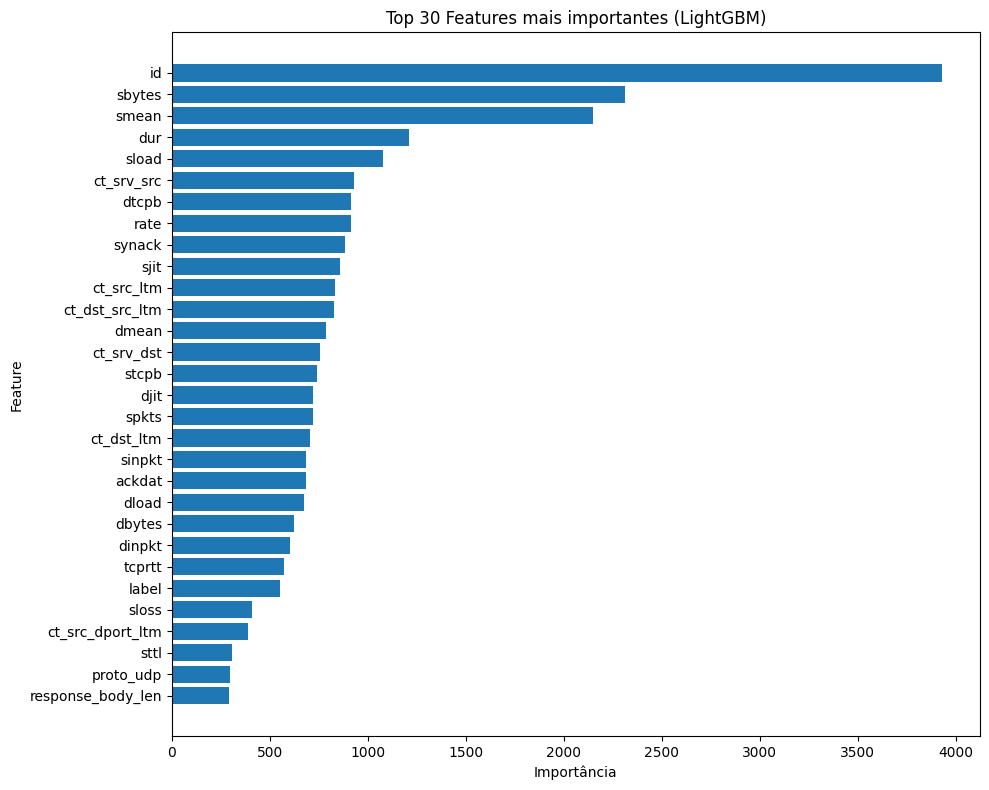

,feature,importance
155,id,3928
159,sbytes,2315
179,smean,2148
156,dur,1211
164,sload,1077
183,ct_srv_src,928
174,dtcpb,917
161,rate,916
177,synack,882
170,sjit,859


In [71]:
# ==========================================
# FEATURE IMPORTANCE (LightGBM)
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# pegar o classificador final dentro do pipeline
clf = model.named_steps['clf']

# pegar importâncias
importances = clf.feature_importances_

# pegar os nomes das colunas após o OneHotEncoder
ohe = model.named_steps['prep'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([cat_feature_names, num_cols])

# juntar em pandas para ordenar
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

fi = fi.sort_values(by='importance', ascending=False)

# Plotar TOP 30
top_n = 30
fi_top = fi.head(top_n)

plt.figure(figsize=(10,8))
plt.barh(fi_top['feature'][::-1], fi_top['importance'][::-1])
plt.title("Top 30 Features mais importantes (LightGBM)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

fi_top


### 15) Identificação da ordem interna das classes no modelo LightGBM
Exibe a lista de classes (categorias de ataque) na ordem interna que o LightGBM utiliza.  
Essa informação é essencial para selecionar corretamente o índice da classe desejada na etapa do SHAP (já que o SHAP multi-classe exige referenciar a classe pelo seu índice numérico).


In [72]:
classes = model.named_steps['clf'].classes_
print(classes)


['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']


### 16) Correção do pré-processamento para compatibilidade com SHAP
Refaz o transformador de pré-processamento com `sparse_output=False` para garantir que o One-Hot Encoding retorne arrays densos (float), evitando erros de incompatibilidade com SHAP em modelos multi-classe.


In [73]:
from sklearn.preprocessing import OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)


### 17) Re-treinamento do modelo após ajuste do pré-processamento
Reconstrói o pipeline usando o novo One-Hot Encoder compatível com SHAP e re-treina o LightGBM.  
Essa etapa é necessária para garantir que o modelo final utilize features numéricas válidas, permitindo que o SHAP funcione corretamente na etapa de explicabilidade.


In [74]:
model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', LGBMClassifier(verbose=-1))
])

model.fit(X_train, y_train)
print("modelo re-treinado com preprocess fixado")


modelo re-treinado com preprocess fixado


### 18) Cálculo dos valores SHAP para explicabilidade do modelo
Calcula os SHAP values para amostras do conjunto de teste, permitindo entender quais variáveis aumentam ou reduzem a probabilidade de cada categoria de ataque.  
O SHAP é usado aqui para interpretar o comportamento interno do modelo LightGBM e explicar, de forma transparente, como cada feature influencia as decisões do classificador.


In [75]:
import shap

X_test_trans = model.named_steps['prep'].transform(X_test)
sample_T = X_test_trans[:200]

explainer = shap.TreeExplainer(model.named_steps['clf'])

shap_values = explainer(sample_T)

print("shap_values OK")


shap_values OK


### 19) Seleção da classe-alvo para interpretação SHAP (Generic)
Seleciona a matriz de SHAP correspondente à classe “Generic” (índice 5), permitindo analisar especificamente quais features mais contribuem para identificar esse tipo de ataque.


In [76]:
class_idx = 5
sv_generic = shap_values[..., class_idx]


### 20) Extração dos nomes finais das features usadas pelo modelo
Obtém diretamente do LightGBM a lista de nomes das features realmente utilizadas no modelo.  
Essa abordagem garante alinhamento perfeito entre as posições das features e os valores SHAP, evitando inconsistências na interpretação.


In [77]:
feature_names_lgb = model.named_steps['clf'].booster_.feature_name()


### 21) Verificação do formato do array de valores SHAP
Mostra o shape da matriz retornada pelo SHAP, revelando a dimensão exata do resultado (samples × features × classes).  
Essa checagem é importante para confirmar como o SHAP indexa features e classes em modelos multi-classe.


In [78]:
print("shap_values.values shape:", shap_values.values.shape)


shap_values.values shape: (200, 196, 10)


### 22) Extração da matriz SHAP somente para a classe Generic
Seleciona do tensor SHAP apenas os valores referentes à classe “Generic” (índice 5), obtendo uma matriz 2D no formato (amostras × features), que é a base para calcular a importância média das variáveis especificamente para este tipo de ataque.


In [79]:
# selecionar classe Generic (índice 5)
class_idx = 5
sv_generic = shap_values.values[:, :, class_idx]

print("sv_generic shape:", sv_generic.shape)


sv_generic shape: (200, 196)


### 23) Criação da tabela de importância média das features (SHAP)
Calcula a importância média absoluta dos valores SHAP por feature e cria uma tabela ordenada da mais influente para a menos influente.  
Esse dataframe `df_shap` representa a explicabilidade quantitativa do modelo, mostrando quais variáveis contribuem mais para classificar ataques do tipo Generic.


In [80]:
df_shap = pd.DataFrame({
    'feature': feature_names_lgb,
    'shap_importance_mean': np.abs(sv_generic).mean(axis=0)
}).sort_values(by='shap_importance_mean', ascending=False)

df_shap.head(20)


,feature,shap_importance_mean
195,Column_195,18963.478367
187,Column_187,14906.717858
193,Column_193,7943.675846
155,Column_155,4851.667148
135,Column_135,3860.015398
184,Column_184,2877.951482
174,Column_174,2774.865521
157,Column_157,2062.829165
185,Column_185,1829.578265
186,Column_186,1728.207089


### 24) Reconstrução dos nomes das features no formato interpretável (human-readable)
Recupera os nomes reais resultantes do One-Hot Encoding (ex.: `proto=udp`, `service=dns`) e os concatena com as features numéricas originais.  
Isso permite substituir identificadores genéricos internos do LightGBM (ex.: Column_193) por nomes compreensíveis para o usuário final.


In [81]:
# reconstruir nomes humanos das features finais

ohe = model.named_steps['prep'].named_transformers_['cat']
ohe_feature_names = list(ohe.get_feature_names_out(cat_cols))

feature_names_human = ohe_feature_names + num_cols  # categóricas + numéricas

len(feature_names_human), len(feature_names_lgb)


(196, 196)

### 25) Verificação de alinhamento entre nomes internos do modelo e nomes humanizados
Confirma se a quantidade de features internas do LightGBM (feature_names_lgb) é igual à quantidade de nomes humanizados reconstruídos.  
Se os números batem, é seguro substituir os nomes internos pelos nomes interpretáveis no dataframe SHAP.


In [82]:
print("LGB names:", len(feature_names_lgb))
print("Human names:", len(feature_names_human))


LGB names: 196
Human names: 196


### 26) Gráfico das 15 features mais relevantes segundo SHAP (para ataques Generic)
Substitui os nomes internos das features pelos nomes interpretáveis (ex.: `proto=udp`, `service=dns`, `state=FIN`), ordena o ranking de importância e gera um gráfico horizontal com as 15 variáveis que mais influenciam a classificação de ataques do tipo “Generic”.  
Este é o ponto central da explicabilidade: aqui o usuário consegue visualizar *quais atributos do tráfego de rede* têm maior peso na decisão do modelo.


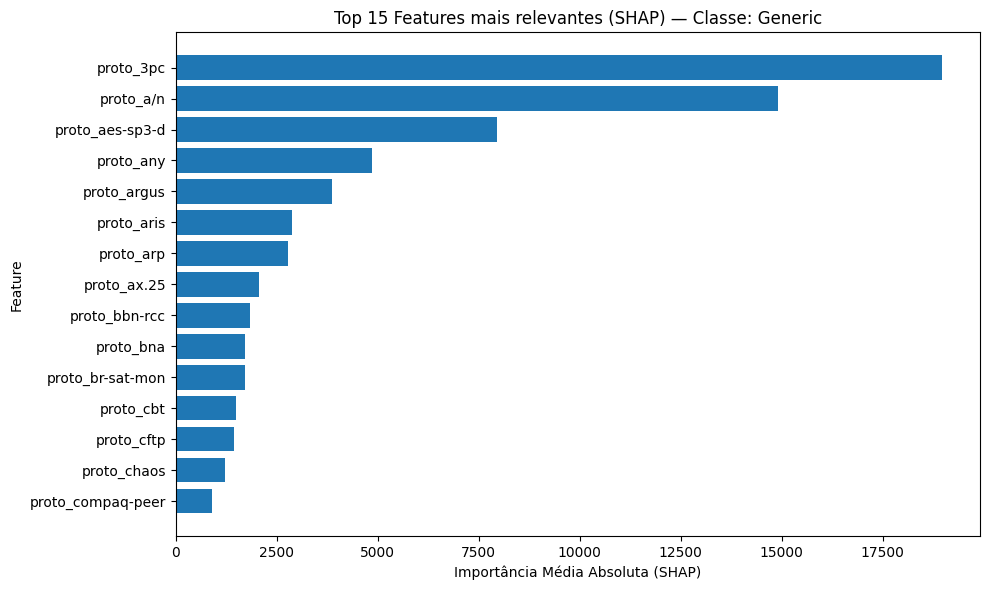

,feature,shap_importance_mean
188,proto_compaq-peer,900.547601
161,proto_chaos,1220.776983
183,proto_cftp,1440.631056
165,proto_cbt,1501.575647
180,proto_br-sat-mon,1719.900288
186,proto_bna,1728.207089
185,proto_bbn-rcc,1829.578265
157,proto_ax.25,2062.829165
174,proto_arp,2774.865521
184,proto_aris,2877.951482


In [83]:
# ========================
# GRÁFICO TOP 15 FEATURES
# ========================

# aplicar nomes humanos na tabela SHAP
df_shap['feature'] = feature_names_human
df_shap = df_shap.sort_values(by='shap_importance_mean', ascending=False)

df_shap.head(20)

top_n = 15
top_df = df_shap.head(top_n).sort_values(by='shap_importance_mean', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(top_df['feature'], top_df['shap_importance_mean'])
plt.title("Top 15 Features mais relevantes (SHAP) — Classe: Generic")
plt.xlabel("Importância Média Absoluta (SHAP)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

top_df


### 27) Gráfico Waterfall SHAP para explicação individual de uma predição
Gera a explicação detalhada de um caso específico (registro individual), mostrando visualmente quais features puxaram a previsão para cima ou para baixo em direção à classe “Generic”.  
Este gráfico representa o nível máximo de transparência do modelo, permitindo entender *por que* aquela amostra foi classificada como ataque.


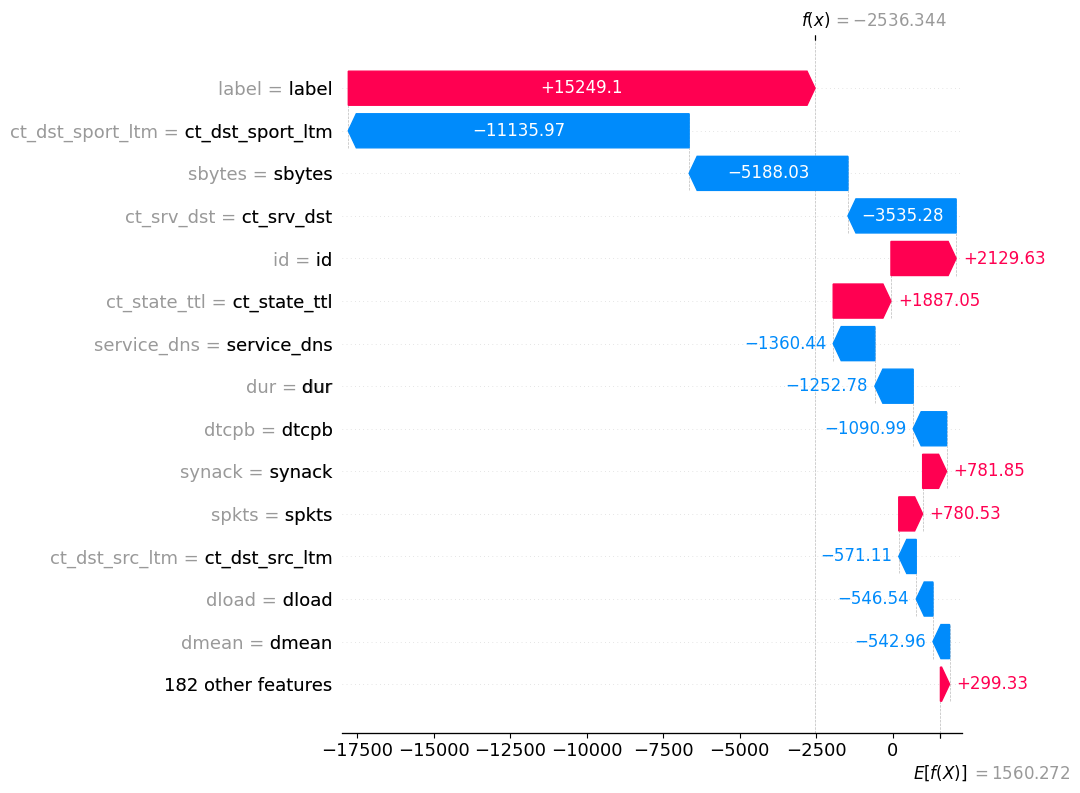

In [84]:
idx = 0  # primeira amostra explicada

shap.plots.waterfall(
    shap.Explanation(
        values = shap_values.values[idx, :, class_idx],
        base_values = shap_values.base_values[idx, class_idx],
        data = feature_names_human,
        feature_names = feature_names_human
    ),
    max_display=15
)
